# Sampling-based algorithms (RRT / RRT*) — exploration visualization

Notebook accompanying the subsection **Sampling-based algorithms** from the chapter *LLMs as planners: Reasoning instead of programming*.

## Concrete task: cleaning robot avoids furniture

Unlike the grid in Dijkstra's algorithm, here the space is **continuous** — the robot can stand in *any* point of the room, not just on a grid square. Discretization of such a space (let alone the configuration space of a 7-DOF arm) is too costly, so instead of searching everything, we **sample randomly**.

Scene:
- **Room** is a 100×100 square (continuous space).
- **Robot** (vacuum cleaner) starts in the corner **(5, 5)** and has to reach the dock **(95, 95)**.
- **Furniture** (sofa, table, cabinet, dresser) are rectangular **obstacles** that cannot be crossed.
- **Cost** = length of the path traveled (Euclidean).

**What we compare:**
- **RRT** — builds an exploration tree by random sampling; finds *some* path very quickly, but it is **tortuous**.
- **RRT\*** — the same idea + *edge rewiring*; with the same sample budget it **shortens** the path towards the optimal one.

## Intuition: exploring in the dark and a growing vine

**RRT = spinning a web in a dark, cluttered room.** You can't see the whole map, so you explore it like this: point to a **random** spot in the room, from the **closest** already explored place take a **small step** towards it and — if you don't hit a piece of furniture — remember this new place. Repeated thousands of times, the "vine" of explored points **instantly fills the free space**. The key trick: random points fall into **large empty areas** more often, so the tree naturally "pulls" towards the unexplored (the so-called Voronoi bias).

This is a different approach than the water in Dijkstra: there we *flooded* every square; here the space is continuous and too large, so instead of flooding everything — we **throw darts and spin a web**.

**RRT\* = straightening a beaten path.** Ordinary RRT connects each new point simply to the closest one — the route comes out tortuous ("just to get there"). RRT\* adds **rewiring**: when a newly added point offers a *shorter route* to a neighbor, we rewire that neighbor to the new, cheaper branch. It's like a **path on a lawn that people shorten over time**, until it approaches the straightest one. Therefore, with the same sample budget, RRT\* returns a **shorter** route (panel c).

> RRT (as well as RRT\*) is **probabilistically complete** — the chance of finding a path approaches 1 as the number of samples increases — but RRT itself **is not optimal**: the first path found is usually significantly longer than the shortest one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
import os

SEED = 7
BOUNDS = (100.0, 100.0)          # room 100 x 100 (continuous space)
START = (5.0, 5.0)               # corner of the room
GOAL = (95.0, 95.0)              # dock / door

# Furniture as rectangles (x0, y0, x1, y1) -- obstacles the robot cannot cross
OBSTACLES = [
    (20, 25, 45, 45),   # sofa
    (58, 55, 82, 78),   # table
    (30, 62, 48, 85),   # cabinet
    (60, 20, 82, 40),   # dresser
]


def w_kolizji(p):
    """Is point p=(x,y) inside any furniture?"""
    x, y = p
    for (x0, y0, x1, y1) in OBSTACLES:
        if x0 <= x <= x1 and y0 <= y <= y1:
            return True
    return False


def krawedz_wolna(a, b, step=1.0):
    """Is the segment a->b collision-free? (sampling every ~step units)"""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    d = np.hypot(*(b - a))
    n = max(2, int(d / step) + 1)
    for t in np.linspace(0.0, 1.0, n):
        if w_kolizji(a + t * (b - a)):
            return False
    return True


def _sciezka(nodes, parent, idx):
    """Reconstructs the path from node idx to the root (using parent pointers)."""
    if idx is None:
        return []
    p = []
    while idx is not None:
        p.append(nodes[idx])
        idx = parent[idx]
    return p[::-1]


def dlugosc(path):
    """Euclidean length of the polyline (inf if no path)."""
    if len(path) < 2:
        return float('inf')
    return float(sum(np.hypot(*(path[i + 1] - path[i])) for i in range(len(path) - 1)))


print('Room', BOUNDS, '| furniture:', len(OBSTACLES))
print('Start (robot):', START, ' Goal:', GOAL)

Room (100.0, 100.0) | furniture: 4
Start (robot): (5.0, 5.0)  Goal: (95.0, 95.0)


## 1. RRT implementation

Four steps of iteration: **sample** a random point → find the **closest** tree node → take a **step** towards the sample → check for **collision** and (if free) add the node. The tree grows for the entire budget, but the route is the **first** connection to the goal — RRT does not improve it.

In [2]:
def rrt(start, goal, step=5.0, p_goal=0.05, max_iter=3000, seed=SEED):
    """Classic RRT. Returns (nodes, parent, path, goal_idx)."""
    rng = np.random.default_rng(seed)
    W, H = BOUNDS
    goal = np.asarray(goal, float)
    nodes = [np.asarray(start, float)]
    parent = [None]
    goal_idx = None

    for _ in range(max_iter):
        q_rand = goal if rng.random() < p_goal else np.array([rng.uniform(0, W), rng.uniform(0, H)])
        pts = np.array(nodes)
        i_near = int(np.argmin(np.hypot(pts[:, 0] - q_rand[0], pts[:, 1] - q_rand[1])))
        q_near = nodes[i_near]
        vec = q_rand - q_near
        dist = np.hypot(*vec)
        if dist < 1e-9:
            continue
        # Tree extension (RRT formula): q_new = q_near + delta*(q_rand-q_near)/||q_rand-q_near||, delta = step
        q_new = q_near + step * vec / dist if dist > step else q_rand.copy()
        if not krawedz_wolna(q_near, q_new):
            continue
        nodes.append(q_new)
        parent.append(i_near)
        # closing to the goal -- only the FIRST route
        if goal_idx is None and np.hypot(*(q_new - goal)) <= step and krawedz_wolna(q_new, goal):
            nodes.append(goal)
            parent.append(len(nodes) - 2)
            goal_idx = len(nodes) - 1

    return nodes, parent, _sciezka(nodes, parent, goal_idx), goal_idx


## 2. RRT* implementation

Two additions compared to RRT: **choosing the best parent** (among neighbors in a radius, the one giving the cheapest route) and **rewiring** — if the new node shortens the route to a neighbor, we rewire that neighbor. The goal is a normal node whose parent can be rewired to a cheaper one, so the route gradually shortens.

> Didactic simplification: local rewiring, without full cost propagation to descendants. It is sufficient to show the route shortening effect.

In [3]:
def rrt_star(start, goal, step=5.0, promien=12.0, p_goal=0.05, max_iter=3000, seed=SEED):
    """RRT* with best parent selection and rewiring. Returns (nodes, parent, path, goal_idx)."""
    rng = np.random.default_rng(seed)
    W, H = BOUNDS
    goal = np.asarray(goal, float)
    nodes = [np.asarray(start, float)]
    parent = [None]
    cost = [0.0]
    goal_idx = None

    for _ in range(max_iter):
        q_rand = goal if rng.random() < p_goal else np.array([rng.uniform(0, W), rng.uniform(0, H)])
        pts = np.array(nodes)
        i_near = int(np.argmin(np.hypot(pts[:, 0] - q_rand[0], pts[:, 1] - q_rand[1])))
        q_near = nodes[i_near]
        vec = q_rand - q_near
        dist = np.hypot(*vec)
        if dist < 1e-9:
            continue
        # Tree extension (RRT formula): q_new = q_near + delta*(q_rand-q_near)/||q_rand-q_near||, delta = step
        q_new = q_near + step * vec / dist if dist > step else q_rand.copy()
        if not krawedz_wolna(q_near, q_new):
            continue

        # Neighborhood in radius r. In the text r(n) = gamma * (log n / n)^(1/d) -- decreasing radius;
        # here constant 'promien' (didactic simplification, clearer rewiring visualization).
        pts = np.array(nodes)
        d = np.hypot(pts[:, 0] - q_new[0], pts[:, 1] - q_new[1])
        cand = np.where(d <= promien)[0]
        blisko = [int(j) for j in cand if krawedz_wolna(nodes[j], q_new)]
        if not blisko:
            blisko = [i_near]

        # MECHANISM 1 -- best parent selection: min_j [ g(j) + ||nodes[j]-q_new|| ], i.e. minimizing g(q_new)
        best = min(blisko, key=lambda j: cost[j] + np.hypot(*(nodes[j] - q_new)))
        idx_new = len(nodes)
        nodes.append(q_new)
        parent.append(best)
        cost.append(cost[best] + np.hypot(*(nodes[best] - q_new)))

        # MECHANISM 2 -- rewiring: if g(q_new) + ||q_new-nodes[j]|| < g(j), rewire neighbor j to q_new
        for j in blisko:
            nowy = cost[idx_new] + np.hypot(*(nodes[j] - q_new))
            if nowy + 1e-9 < cost[j] and krawedz_wolna(q_new, nodes[j]):
                parent[j] = idx_new
                cost[j] = nowy

        # closing / improving the route to the goal
        if np.hypot(*(q_new - goal)) <= step and krawedz_wolna(q_new, goal):
            g_new = cost[idx_new] + np.hypot(*(q_new - goal))
            if goal_idx is None:
                nodes.append(goal)
                parent.append(idx_new)
                cost.append(g_new)
                goal_idx = len(nodes) - 1
            elif g_new + 1e-9 < cost[goal_idx]:
                parent[goal_idx] = idx_new
                cost[goal_idx] = g_new

    return nodes, parent, _sciezka(nodes, parent, goal_idx), goal_idx


## 3. Execution and metrics

In [4]:
nodes_r, par_r, path_r, gi_r = rrt(START, GOAL)
nodes_s, par_s, path_s, gi_s = rrt_star(START, GOAL)

len_r = dlugosc(path_r)
len_s = dlugosc(path_s)
prosta = np.hypot(GOAL[0] - START[0], GOAL[1] - START[1])

print(f'RRT : nodes = {len(nodes_r)}, path length = {len_r:.1f}')
print(f'RRT*: nodes = {len(nodes_s)}, path length = {len_s:.1f}')
print(f'Lower bound (straight line, ignores furniture) = {prosta:.1f}')
if np.isfinite(len_r) and np.isfinite(len_s):
    print(f'RRT* shortened the path by {100 * (1 - len_s / len_r):.0f}% compared to RRT '
          f'(same sample budget).')

RRT : nodes = 2265, path length = 167.6
RRT*: nodes = 2265, path length = 134.9
Lower bound (straight line, ignores furniture) = 127.3
RRT* shortened the path by 20% compared to RRT (same sample budget).


## 4. Visualization

The figure is saved to `../figures/rrt_exploration.pdf` and inserted into the chapter.
- **(a)** RRT tree (gray) + first, tortuous route (blue);
- **(b)** RRT\* tree + shorter route (green) thanks to rewiring;
- **(c)** comparison of both routes against the background of furniture.

Saved: chapter_5/figures/rrt_exploration.{pdf,png}


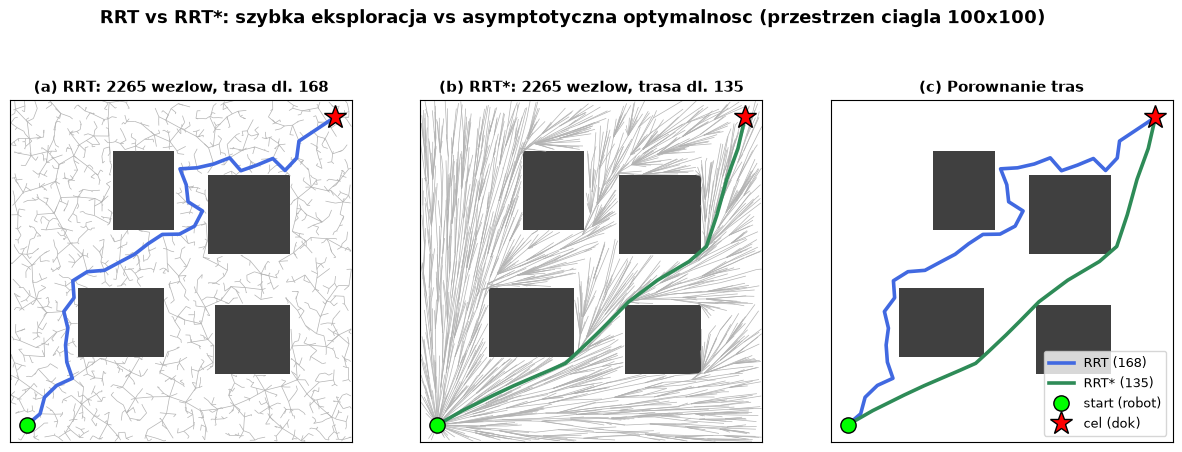

In [5]:
def _meble(ax):
    for (x0, y0, x1, y1) in OBSTACLES:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                               facecolor='0.25', edgecolor='none', zorder=1))


def _drzewo(ax, nodes, parent, kolor='0.7'):
    seg = [[nodes[p], nodes[i]] for i, p in enumerate(parent) if p is not None]
    ax.add_collection(LineCollection(seg, colors=kolor, linewidths=0.5, zorder=2))


def _markery(ax):
    ax.plot(*START, 'o', color='lime', markersize=11, markeredgecolor='black',
            zorder=5, label='start (robot)')
    ax.plot(*GOAL, '*', color='red', markersize=17, markeredgecolor='black',
            zorder=5, label='goal (dock)')


def _trasa(ax, path, kolor, etykieta):
    if len(path) >= 2:
        P = np.array(path)
        ax.plot(P[:, 0], P[:, 1], color=kolor, linewidth=2.6, zorder=4, label=etykieta)


def _sceneria(ax, tytul):
    ax.set_xlim(0, BOUNDS[0])
    ax.set_ylim(0, BOUNDS[1])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(tytul, fontsize=11, fontweight='bold')


fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))

_meble(axes[0]); _drzewo(axes[0], nodes_r, par_r); _trasa(axes[0], path_r, 'royalblue', 'RRT path'); _markery(axes[0])
_sceneria(axes[0], f'(a) RRT: {len(nodes_r)} nodes, path len {len_r:.0f}')

_meble(axes[1]); _drzewo(axes[1], nodes_s, par_s); _trasa(axes[1], path_s, 'seagreen', 'RRT* path'); _markery(axes[1])
_sceneria(axes[1], f'(b) RRT*: {len(nodes_s)} nodes, path len {len_s:.0f}')

_meble(axes[2]); _trasa(axes[2], path_r, 'royalblue', f'RRT ({len_r:.0f})'); _trasa(axes[2], path_s, 'seagreen', f'RRT* ({len_s:.0f})'); _markery(axes[2])
_sceneria(axes[2], '(c) Path comparison')
axes[2].legend(loc='lower right', fontsize=9)

fig.suptitle('RRT vs RRT*: rapid exploration vs asymptotic optimality (continuous space 100x100)',
             fontsize=13, fontweight='bold')

os.makedirs('../rysunki', exist_ok=True)
fig.savefig('../figures/rrt_exploration.pdf', bbox_inches='tight')
fig.savefig('../figures/rrt_exploration.png', dpi=150, bbox_inches='tight')
print('Saved: chapter_5/figures/rrt_exploration.{pdf,png}')
plt.show()

## 5. Conclusions

- **RRT** explores instantly and is probabilistically complete, but its first path is **tortuous and suboptimal** (panel a).
- **RRT\*** with the same sample budget **shortens** the path thanks to edge rewiring — a practical illustration of *asymptotic optimality* (panels b, c).
- **Where the differences come from:** both build a tree by the same random sampling; the difference is that RRT\* constantly **improves** connections (rewiring), while RRT stops at the first route.
- In **continuous / high-dimensional** spaces (robot arm, drone), sampling is often the only practical option — discretization like in Dijkstra/A\* is computationally infeasible there.

Source references: S. M. LaValle, *Planning Algorithms* (2006) and S. Karaman, E. Frazzoli, *Sampling-based Algorithms for Optimal Motion Planning* (2011).